In [1]:
import pandas as pd
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
data = {

"Email":[

"Your account has been suspended verify your details immediately",

"Team meeting will be conducted on Monday at 9 AM",

"You have won a $5000 reward click here to claim",

"Please find the attached project report for review",

"Limited time offer get 70 percent discount on shopping",

"Your electricity bill payment was successful",

"Congratulations you are selected for a free gift card",

"Can you send me the monthly sales report",

"Urgent your bank account needs verification to avoid closure",

"Your password was changed successfully",

"Earn money online without investment register now",

"The interview is scheduled for next week",

"Exclusive deal buy one get one free",

"Your package has been shipped and will arrive tomorrow",

"Please complete the employee feedback form",

"Claim your free vacation package today",

"Your loan application has been approved",

"Let's discuss the project requirements tomorrow",

"Winner announcement click the link to receive prize",

"Your mobile recharge was completed successfully"

],


"Category":[

"Spam",
"Ham",
"Spam",
"Ham",
"Spam",
"Ham",
"Spam",
"Ham",
"Spam",
"Ham",
"Spam",
"Ham",
"Spam",
"Ham",
"Ham",
"Spam",
"Spam",
"Ham",
"Spam",
"Ham"

]

}


df = pd.DataFrame(data)


df.head()

,Email,Category
0,Your account has been suspended verify your de...,Spam
1,Team meeting will be conducted on Monday at 9 AM,Ham
2,You have won a $5000 reward click here to claim,Spam
3,Please find the attached project report for re...,Ham
4,Limited time offer get 70 percent discount on ...,Spam


In [3]:
def clean_text(text):

    text = text.lower()

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    text = " ".join(text.split())

    return text


df["Cleaned_Email"] = df["Email"].apply(clean_text)


df.head()

,Email,Category,Cleaned_Email
0,Your account has been suspended verify your de...,Spam,your account has been suspended verify your de...
1,Team meeting will be conducted on Monday at 9 AM,Ham,team meeting will be conducted on monday at 9 am
2,You have won a $5000 reward click here to claim,Spam,you have won a 5000 reward click here to claim
3,Please find the attached project report for re...,Ham,please find the attached project report for re...
4,Limited time offer get 70 percent discount on ...,Spam,limited time offer get 70 percent discount on ...


In [4]:
tfidf = TfidfVectorizer()


X = tfidf.fit_transform(
    df["Cleaned_Email"]
)


y = df["Category"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [6]:
model = MultinomialNB()


model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [7]:
y_pred = model.predict(X_test)


print("Predicted Emails:")

print(y_pred)

Predicted Emails:
['Ham' 'Ham' 'Spam' 'Ham' 'Spam' 'Ham']


In [8]:
accuracy = accuracy_score(
    y_test,
    y_pred
)


print("Accuracy:", accuracy)


print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.8333333333333334

Classification Report
              precision    recall  f1-score   support

         Ham       0.75      1.00      0.86         3
        Spam       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



In [9]:
cm = confusion_matrix(
    y_test,
    y_pred
)


print("Confusion Matrix")

print(cm)

Confusion Matrix
[[3 0]
 [1 2]]


In [10]:
print("====== EMAIL SPAM ANALYSIS REPORT ======")

print("\nTotal Emails:",len(df))


print("\nEmail Type Count:")

print(df["Category"].value_counts())


print("\nSpam Percentage:")

spam_percentage = (
    (df["Category"]=="Spam").sum()
    /
    len(df)
)*100


print(round(spam_percentage,2),"%")

====== EMAIL SPAM ANALYSIS REPORT ======

Total Emails: 20

Email Type Count:
Category
Spam    10
Ham     10
Name: count, dtype: int64

Spam Percentage:
50.0 %


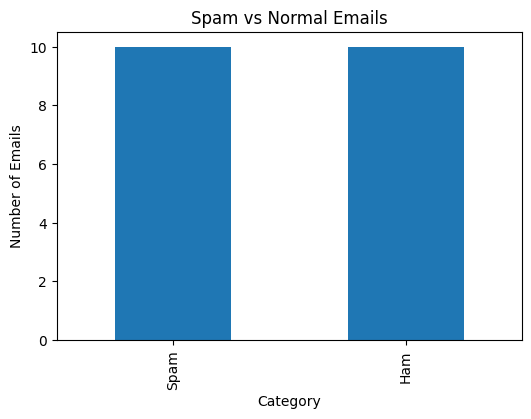

In [11]:
df["Category"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)


plt.title("Spam vs Normal Emails")

plt.xlabel("Category")

plt.ylabel("Number of Emails")

plt.show()